# Experimento Validação

- 10 episódios de Teste
- 10 episódios de Validação
- 20 agentes

* Cada agente é treinado com todos os passos dos episódios de teste exceto o último e testado no último passo
* Resultado intermedário é a médias do RMSE dos agentes em cada episódio de teste
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é a médias do RMSE dos agentes em cada passo dos episódios de teste

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pmbrl.model import *
from pmbrl.data import *
from pmbrl.experiment import *


In [49]:
n_episodes = 10

data = [generate_episode() for _ in range(n_episodes)]
for i in data:
    print(i.shape)

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(


(19, 8)
(14, 8)
(26, 8)
(24, 8)
(10, 8)
(48, 8)
(21, 8)
(28, 8)
(44, 8)
(39, 8)


In [50]:
n_agents = 20

pmbrl = [Model(learning_rate=[0.0001,0.001]) for _ in range(n_agents)]
mbrl = [ModelBase(learning_rate=[0.0001,0.001]) for _ in range(n_agents)]

In [51]:
training = { # Traning:
    "mode": "all", # Mode of the PMBRL (All: learn parameters and Transitions)
    "debug": False, # Number of epochs on training
    "num_epochs": 1000, # Number of epochs on training
}

def run(data, models, verbose=False):
    results = []
    for i, epi in enumerate(data):
        if verbose:
            print(f'Episode {i}...')
        X, y = build_train_data(epi)
        for j, agent in enumerate(models):
            if verbose:
                print(f'Agent {j}...')
            agent.train(X[:-1], y[:-1], **training)
            s,r = agent.sample(X[-1:], mode=training['mode'])
            results.append(
                torch.concat([
                    torch.tensor([i, j]),
                    torch.mean((s - y[-1:,:-1])**2, axis=0)**.5,
                    torch.mean((r - y[-1:,-1])**2, axis=0)**.5
                ], axis=0)
            )
    return pd.DataFrame(np.array(results), columns=['epi', 'agent', 's_0', 's_1', 'r']) 

# pmbrl_results = run(data, pmbrl)
# mbrl_results = run(data, mbrl)

In [52]:
print('Training pmbrl...')
pmbrl_results = run(data, pmbrl, verbose=True)
print('pmbrl done!')

pmbrl_plot = pmbrl_results.groupby(by='epi').mean()[['s_0','s_1','r']]

Training pmbrl...
Episode 0...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 1...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 2...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 3...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 4.

In [53]:
print('Training mbrl...')
mbrl_results = run(data, mbrl, verbose=True)
print('mbrl done!')

mbrl_plot = mbrl_results.groupby(by='epi').mean()[['s_0','s_1','r']]

Training mbrl...
Episode 0...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 1...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 2...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 3...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 4..

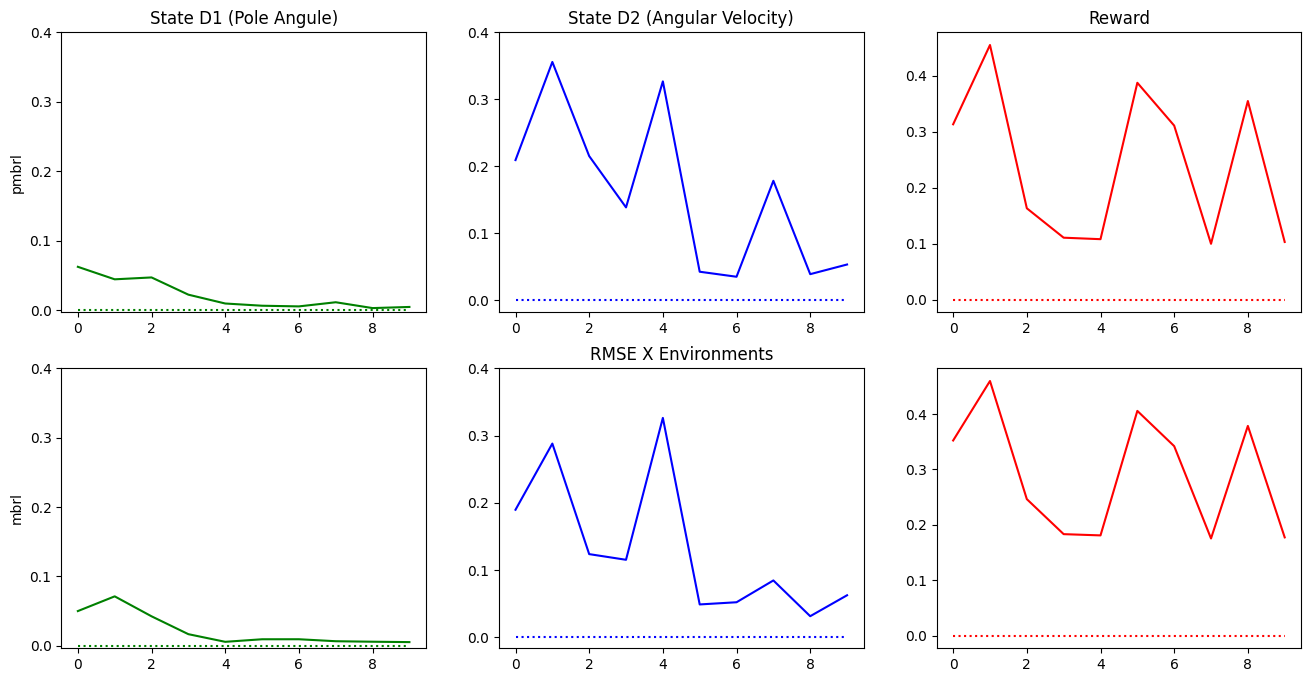

In [54]:
def add_plot(name, data, axis):
    reff = np.zeros(data.shape[0])
    axis[0].set_ylabel(name)
    axis[0].set_ylabel(name)

    axis[0].plot(data['s_0'], color = 'g')
    axis[0].plot(reff, linestyle = 'dotted', color = 'g')
    axis[0].set_yticks(np.arange(5)/10)

    axis[1].plot(data['s_1'], color = 'b')
    axis[1].plot(reff, linestyle = 'dotted', color = 'b')
    axis[1].set_yticks(np.arange(5)/10)

    axis[2].plot(data['r'], color = 'r')
    axis[2].plot(reff, linestyle = 'dotted', color = 'r')
    axis[2].set_yticks(np.arange(5)/10)

fig, axs = plt.subplots(2, 3, figsize=(16, 8))

axs[0][0].set_title('State D1 (Pole Angule)')
axs[0][1].set_title('State D2 (Angular Velocity)')
axs[0][2].set_title('Reward')
axs[1][1].set_title('RMSE X Environments')

add_plot('pmbrl', pmbrl_plot, axs[0])
add_plot('mbrl', mbrl_plot, axs[1])

plt.show()

# Teste

In [55]:
n_episodes = 10

data = [generate_episode() for _ in range(n_episodes)]
for i in data:
    print(i.shape)

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/rlenvs/cart_pole_custom.py:126: RuntimeWarning: divide by zero encountered in scalar divide
  thetaacc = (self.gravity * sintheta - costheta * temp) / (
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/rlenvs/cart_pole_custom.py:130: RuntimeWarning: invalid value encountered in sca

(100, 8)
(78, 8)
(16, 8)
(44, 8)
(42, 8)
(1, 8)
(32, 8)
(75, 8)
(17, 8)
(14, 8)


In [56]:
X, y = build_train_data(data[0])
# X[0:1]
# for k, (feature, target) in enumerate(zip(X,y)):
#     print(torch.unsqueeze(feature, axis=0))

pmbrl[0].sample(torch.unsqueeze(X[0], axis=0), mode=training['mode'])

(tensor([[-0.0274, -0.1427]]), tensor([[0.9536]]))

In [57]:
def run(data, models, verbose=False):
    results = []
    for i, epi in enumerate(data):
        if verbose:
            print(f'Episode {i}...')
        X, y = build_train_data(epi)
        for j, agent in enumerate(models):
            if verbose:
                print(f'Agent {j}...')
            for k, (feature, target) in enumerate(zip(X,y)):
                s,r = agent.sample(torch.unsqueeze(feature, axis=0), mode=training['mode'])
                results.append(
                    torch.concat([
                        torch.tensor([i, j, k]),
                        torch.mean((s - target[:-1])**2, axis=0)**.5,
                        torch.mean((r - target[-1])**2, axis=0)**.5
                    ], axis=0)
                )
    return pd.DataFrame(np.array(results), columns=['epi', 'agent', 'step', 's_0', 's_1', 'r']) 


In [58]:
print('Training pmbrl...')
pmbrl_results = run(data, pmbrl, verbose=True)
print('pmbrl done!')

pmbrl_plot = pmbrl_results.groupby(by='step').mean()[['s_0','s_1','r']]

Training pmbrl...
Episode 0...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 1...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 2...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 3...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 4.

In [59]:
print('Training mbrl...')
mbrl_results = run(data, mbrl, verbose=True)
print('mbrl done!')

mbrl_plot = mbrl_results.groupby(by='step').mean()[['s_0','s_1','r']]

Training mbrl...
Episode 0...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 1...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 2...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 3...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 4..

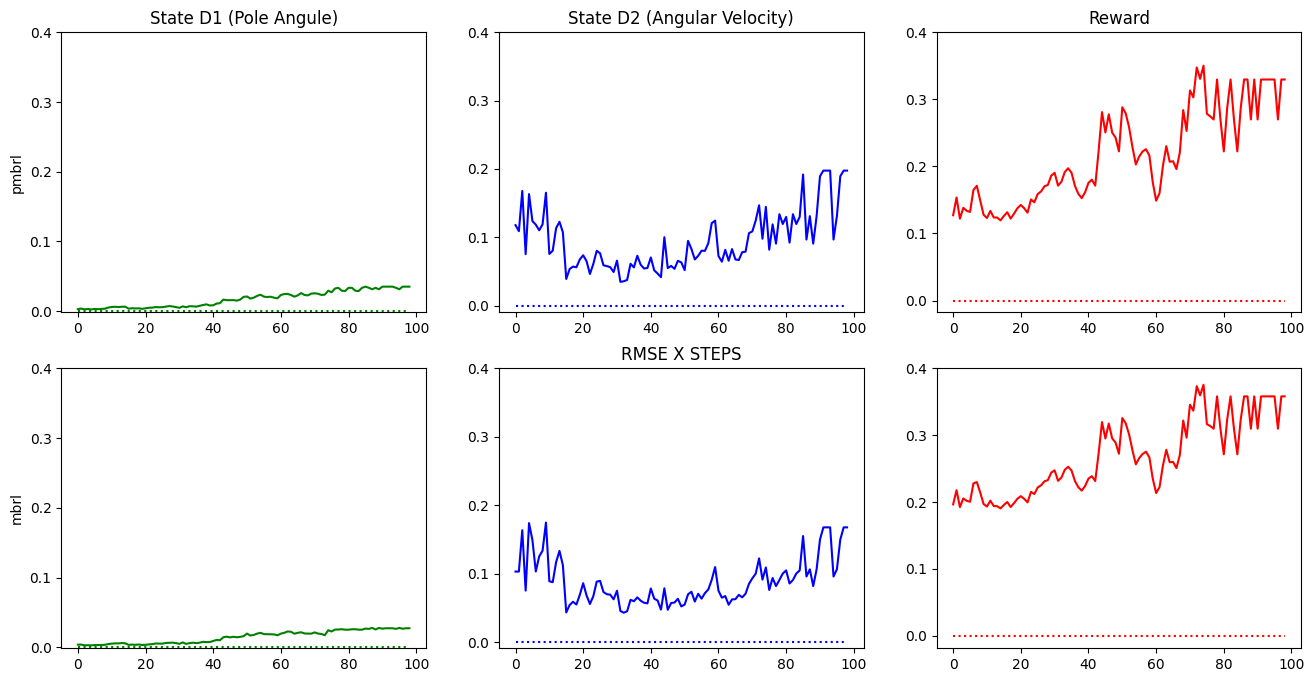

In [60]:
fig, axs = plt.subplots(2, 3, figsize=(16, 8))

axs[0][0].set_title('State D1 (Pole Angule)')
axs[0][1].set_title('State D2 (Angular Velocity)')
axs[0][2].set_title('Reward')
axs[1][1].set_title('RMSE X STEPS')

add_plot('pmbrl', pmbrl_plot, axs[0])
add_plot('mbrl', mbrl_plot, axs[1])

plt.show()